In [ ]:
import numpy as np
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from pathlib import Path
from tqdm.notebook import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATA_DIR = Path("../dataset/preprocessed")

SIGNS_TARGET = [
    "SOUFFRIR", "AIDER",    "FORT",     "MALADE",   "COEUR",
    "TETE",     "MORT",     "DOS",      "VENTRE",   "FROID",
    "JAMBE",    "JAMBES",   "RESPIRER", "ACCIDENT", "FAIBLE",
    "ENCEINTE", "DIABETE",  "BRAS",     "DOSSIER",  "EFFORT"
]
NUM_CLASSES = len(SIGNS_TARGET)
IDX_TO_SIGN = {i: s for i, s in enumerate(SIGNS_TARGET)}

Using device: cuda


In [2]:
class PoseHeatmapDataset(Dataset):
    """
    Wraps the preprocessed heatmap tensors.
    X shape: (N, 3, T, H, W)  float32
    y shape: (N,)              int64
    """
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.from_numpy(X)  # (N, 3, T, H, W)
        self.y = torch.from_numpy(y)  # (N,)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# Load data
X_train = np.load(DATA_DIR / "X_train.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
X_test  = np.load(DATA_DIR / "X_test.npy")
y_test  = np.load(DATA_DIR / "y_test.npy")

print(f"Train: {X_train.shape}, labels: {y_train.shape}")
print(f"Test:  {X_test.shape},  labels: {y_test.shape}")

train_dataset = PoseHeatmapDataset(X_train, y_train)
test_dataset  = PoseHeatmapDataset(X_test,  y_test)

Train: (2428, 3, 32, 64, 64), labels: (2428,)
Test:  (380, 3, 32, 64, 64),  labels: (380,)


In [3]:
# Build a WeightedRandomSampler so rare classes are sampled more often
class_counts   = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
# Multiply by 4 because training set was augmented 4x
class_weights  = 1.0 / np.maximum(class_counts, 1.0)
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float32),
    num_samples = len(y_train),
    replacement = True,
)

train_loader = DataLoader(train_dataset, batch_size=8,  sampler=sampler,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=8,  shuffle=False,    num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

# Verify one batch
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape}, y: {yb.shape}, dtype: {xb.dtype}")

Train batches: 304, Test batches: 48
Batch X: torch.Size([8, 3, 32, 64, 64]), y: torch.Size([8]), dtype: torch.float32


In [4]:
class Unit3D(nn.Module):
    """3D conv + BN + ReLU. Applies 'same' padding automatically."""

    def __init__(self, in_channels: int, out_channels: int,
                 kernel_size=(1, 1, 1), stride=(1, 1, 1),
                 padding=0, activation=True, use_bn=True):
        super().__init__()
        self.conv = nn.Conv3d(
            in_channels, out_channels,
            kernel_size=kernel_size, stride=stride,
            padding=padding, bias=False,
        )
        self.bn   = nn.BatchNorm3d(out_channels, eps=1e-3, momentum=0.001) if use_bn else nn.Identity()
        self.relu = nn.ReLU(inplace=True) if activation else nn.Identity()

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))

In [5]:
class InceptionModule(nn.Module):
    """
    I3D Inception module with 4 branches:
      Branch 0: 1x1x1 conv
      Branch 1: 1x1x1 -> 3x3x3 conv
      Branch 2: 1x1x1 -> 3x3x3 conv  (second path)
      Branch 3: 3x3x3 max pool -> 1x1x1 conv
    """

    def __init__(self, in_channels: int,
                 out_b0: int,
                 out_b1_reduce: int, out_b1: int,
                 out_b2_reduce: int, out_b2: int,
                 out_b3: int):
        super().__init__()
        self.branch0 = Unit3D(in_channels, out_b0, kernel_size=(1, 1, 1))

        self.branch1 = nn.Sequential(
            Unit3D(in_channels, out_b1_reduce, kernel_size=(1, 1, 1)),
            Unit3D(out_b1_reduce, out_b1,      kernel_size=(3, 3, 3), padding=(1, 1, 1)),
        )

        self.branch2 = nn.Sequential(
            Unit3D(in_channels, out_b2_reduce, kernel_size=(1, 1, 1)),
            Unit3D(out_b2_reduce, out_b2,      kernel_size=(3, 3, 3), padding=(1, 1, 1)),
        )

        self.branch3 = nn.Sequential(
            nn.MaxPool3d(kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1)),
            Unit3D(in_channels, out_b3, kernel_size=(1, 1, 1)),
        )

    def forward(self, x):
        b0 = self.branch0(x)
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        return torch.cat([b0, b1, b2, b3], dim=1)

In [6]:
class InceptionI3D(nn.Module):
    """
    Inflated 3D Convolution Network (I3D) adapted for skeleton heatmap input.

    Input:  (batch, 3, T=32, H=64, W=64)
    Output: (batch, num_classes)

    Architecture follows Carreira & Zisserman (2017), Inception-v1 backbone inflated
    to 3D. Spatial pooling is adapted for 64x64 input (vs 224x224 in the original).
    """

    def __init__(self, num_classes: int = 20, in_channels: int = 3,
                 dropout_prob: float = 0.5):
        super().__init__()

        # --- Stem ---
        self.conv3d_1a = Unit3D(in_channels, 64, kernel_size=(7, 7, 7),
                                stride=(2, 2, 2), padding=(3, 3, 3))
        self.maxpool_2a = nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2),
                                       padding=(0, 1, 1))
        self.conv3d_2b = Unit3D(64, 64,  kernel_size=(1, 1, 1))
        self.conv3d_2c = Unit3D(64, 192, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.maxpool_3a = nn.MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2),
                                       padding=(0, 1, 1))

        # --- Mixed (Inception) blocks ---
        self.mixed_3b = InceptionModule(192,  64,  96, 128, 16,  32,  32)
        self.mixed_3c = InceptionModule(256, 128, 128, 192, 32,  96,  64)
        self.maxpool_4a = nn.MaxPool3d(kernel_size=(3, 3, 3), stride=(2, 2, 2),
                                       padding=(1, 1, 1))

        self.mixed_4b = InceptionModule(480, 192,  96, 208, 16,  48,  64)
        self.mixed_4c = InceptionModule(512, 160, 112, 224, 24,  64,  64)
        self.mixed_4d = InceptionModule(512, 128, 128, 256, 24,  64,  64)
        self.mixed_4e = InceptionModule(512, 112, 144, 288, 32,  64,  64)
        self.mixed_4f = InceptionModule(528, 256, 160, 320, 32, 128, 128)
        self.maxpool_5a = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2),
                                       padding=(0, 0, 0))

        self.mixed_5b = InceptionModule(832, 256, 160, 320, 32, 128, 128)
        self.mixed_5c = InceptionModule(832, 384, 192, 384, 48, 128, 128)

        # --- Head ---
        self.avg_pool = nn.AdaptiveAvgPool3d((1, 1, 1))
        self.dropout  = nn.Dropout(p=dropout_prob)
        self.logits   = nn.Linear(1024, num_classes)

    def forward(self, x):
        # x: (B, 3, T, H, W)
        x = self.conv3d_1a(x)
        x = self.maxpool_2a(x)
        x = self.conv3d_2b(x)
        x = self.conv3d_2c(x)
        x = self.maxpool_3a(x)
        x = self.mixed_3b(x)
        x = self.mixed_3c(x)
        x = self.maxpool_4a(x)
        x = self.mixed_4b(x)
        x = self.mixed_4c(x)
        x = self.mixed_4d(x)
        x = self.mixed_4e(x)
        x = self.mixed_4f(x)
        x = self.maxpool_5a(x)
        x = self.mixed_5b(x)
        x = self.mixed_5c(x)
        x = self.avg_pool(x)          # (B, 1024, 1, 1, 1)
        x = x.flatten(1)              # (B, 1024)
        x = self.dropout(x)
        return self.logits(x)         # (B, num_classes)


# Instantiate and verify forward pass
model = InceptionI3D(num_classes=NUM_CLASSES, dropout_prob=0.5).to(DEVICE)
dummy = torch.randn(2, 3, 32, 64, 64).to(DEVICE)
out   = model(dummy)
assert out.shape == (2, NUM_CLASSES), f"Expected (2, {NUM_CLASSES}), got {out.shape}"
print(f"I3D output shape: {out.shape}  [OK]")

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

I3D output shape: torch.Size([2, 20])  [OK]
Total parameters: 12,307,764


In [9]:
import os

os.makedirs("../models", exist_ok=True)

# Class weights for cross-entropy (inverse frequency, from original train counts)
raw_counts    = np.bincount(np.load(DATA_DIR / "y_train.npy"), minlength=NUM_CLASSES)
# raw_counts reflects augmentation (all classes x4)
# Divide by 4 to get original frequency for weight computation
orig_counts   = np.maximum(raw_counts / 4, 1).astype(np.float32)
ce_weights    = torch.tensor(1.0 / orig_counts, dtype=torch.float32).to(DEVICE)
ce_weights   /= ce_weights.sum()  # normalise

criterion = nn.CrossEntropyLoss(weight=ce_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

print("Loss, optimizer, and scheduler defined.")

Loss, optimizer, and scheduler defined.


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds       = logits.argmax(1)
            correct    += (preds == y_batch).sum().item()
            total      += len(y_batch)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    avg_loss = total_loss / total
    accuracy = correct / total
    f1       = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, accuracy, f1, np.array(all_preds), np.array(all_labels)


print("train_one_epoch and evaluate defined.")

train_one_epoch and evaluate defined.


In [12]:
NUM_EPOCHS     = 50
PATIENCE       = 10
best_val_acc   = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    scheduler.step(val_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
              f"train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.3f} f1={val_f1:.3f}")

    # Early stopping + checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), "../models/best_i3d.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 001/50 | train loss=1.4924 acc=0.300 | val loss=3.0339 acc=0.018 f1=0.002
Epoch 005/50 | train loss=0.4803 acc=0.649 | val loss=3.4699 acc=0.018 f1=0.002
Epoch 010/50 | train loss=0.0802 acc=0.864 | val loss=4.8856 acc=0.000 f1=0.000
Early stopping at epoch 11 (no improvement for 10 epochs)
Best validation accuracy: 0.0184


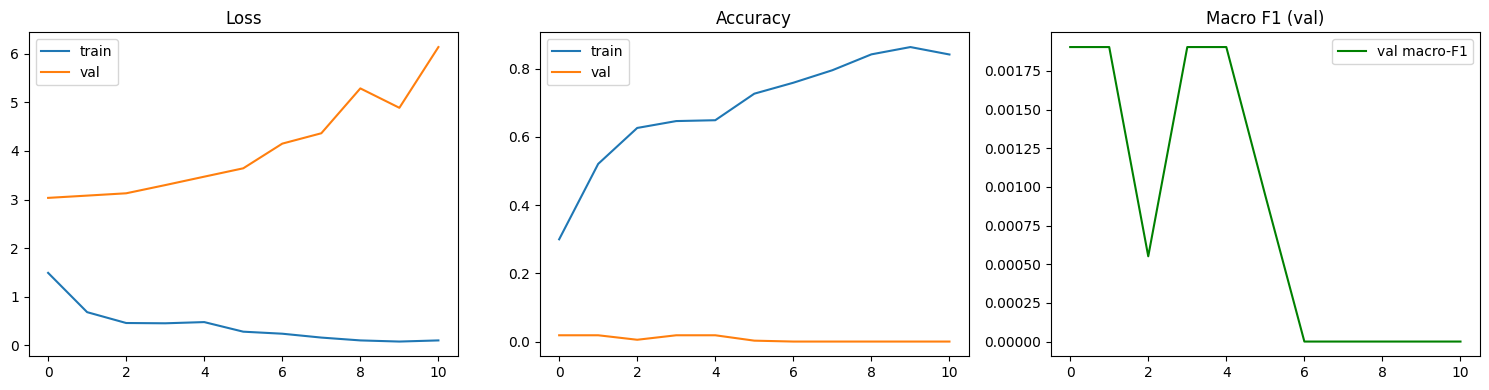

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

axes[2].plot(history["val_f1"], label="val macro-F1", color="green")
axes[2].set_title("Macro F1 (val)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# Load best checkpoint
model.load_state_dict(torch.load("../models/best_i3d.pth", map_location=DEVICE))

_, test_acc, test_f1, preds, labels = evaluate(model, test_loader, criterion, DEVICE)

print(f"Test Accuracy:   {test_acc:.4f}")
print(f"Test Macro-F1:   {test_f1:.4f}")
print()
print(classification_report(
    labels, preds,
    labels=list(range(NUM_CLASSES)),
    target_names=SIGNS_TARGET,
    zero_division=0,
))

Test Accuracy:   0.0184
Test Macro-F1:   0.0019

              precision    recall  f1-score   support

    SOUFFRIR       0.00      0.00      0.00        17
       AIDER       0.00      0.00      0.00        53
        FORT       0.00      0.00      0.00       205
      MALADE       0.00      0.00      0.00         9
       COEUR       0.00      0.00      0.00         9
        TETE       0.00      0.00      0.00        14
        MORT       0.00      0.00      0.00        12
         DOS       0.00      0.00      0.00         2
      VENTRE       0.00      0.00      0.00         2
       FROID       0.00      0.00      0.00        22
       JAMBE       0.00      0.00      0.00         2
      JAMBES       0.00      0.00      0.00         1
    RESPIRER       0.00      0.00      0.00         3
    ACCIDENT       0.00      0.00      0.00         4
      FAIBLE       0.00      0.00      0.00         0
    ENCEINTE       0.00      0.00      0.00        14
     DIABETE       0.00      0.0

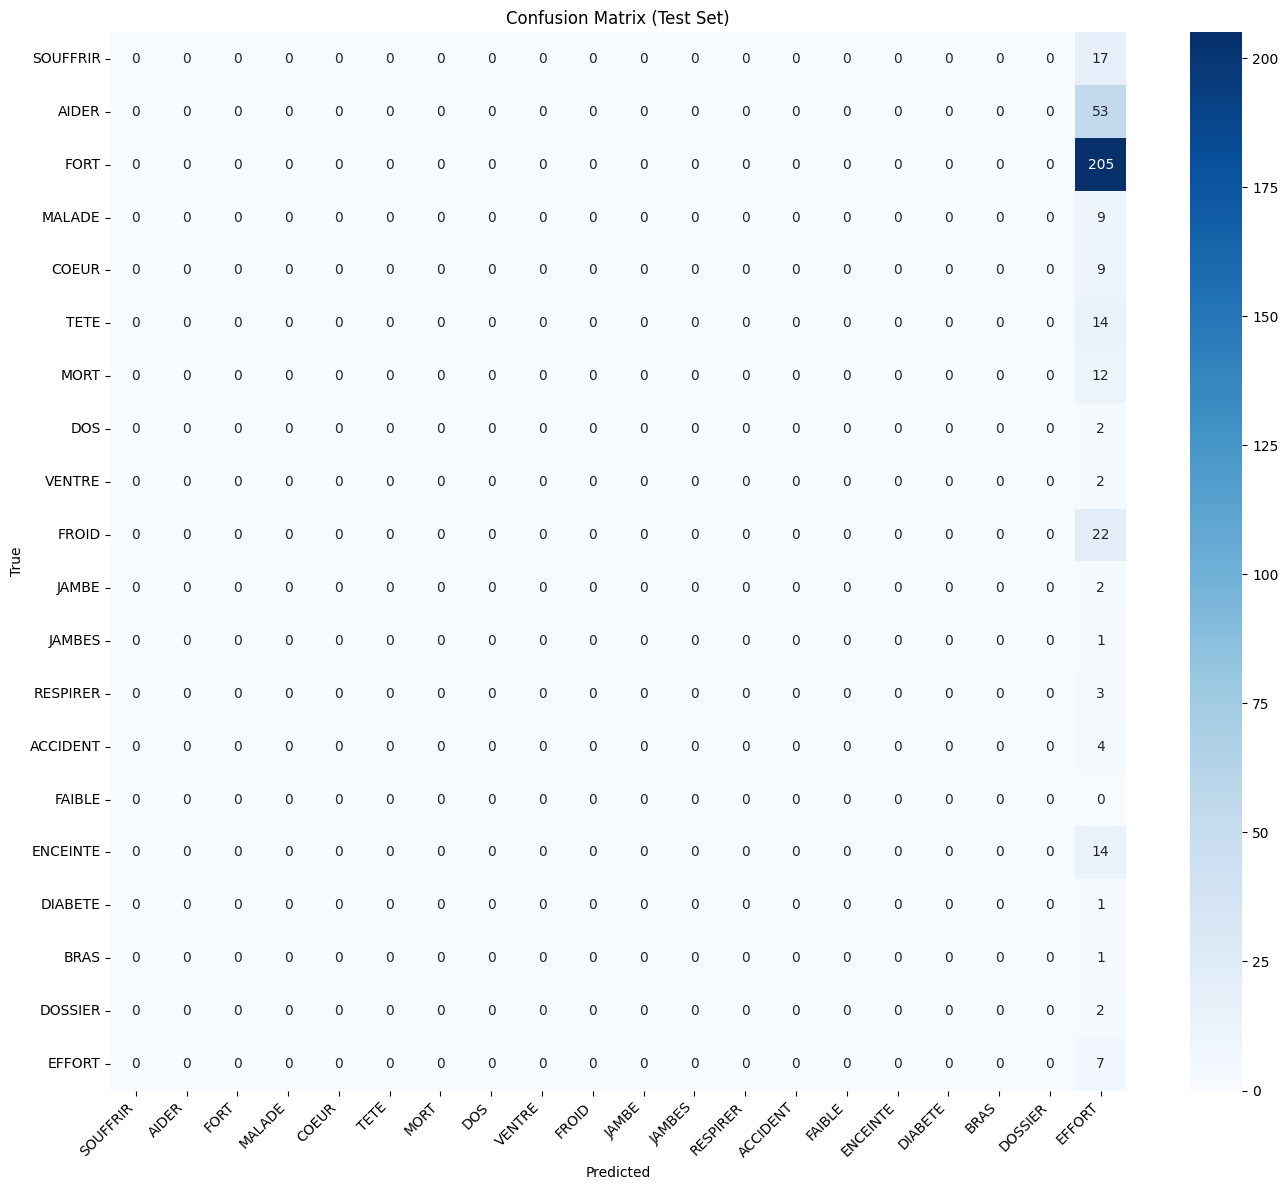

In [19]:
cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=SIGNS_TARGET,
    yticklabels=SIGNS_TARGET,
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [20]:
def save_model(model: nn.Module, path: str, metadata: dict = None):
    """
    Save the trained I3D model weights and optional metadata to disk.

    Args:
        model:    trained InceptionI3D instance
        path:     file path (e.g. '../models/i3d_final.pth')
        metadata: optional dict with training info (e.g. accuracy, epochs, sign_to_idx)
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {"state_dict": model.state_dict()}
    if metadata:
        payload["metadata"] = metadata
    torch.save(payload, path)
    print(f"Model saved to {path}")


def load_model(path: str, num_classes: int = 20) -> InceptionI3D:
    """
    Load a previously saved model from disk.

    Args:
        path:        path to the .pth file saved by save_model
        num_classes: number of output classes (default 20)

    Returns:
        InceptionI3D instance in eval mode
    """
    payload = torch.load(path, map_location=torch.device("cpu"))
    m = InceptionI3D(num_classes=num_classes)
    m.load_state_dict(payload["state_dict"])
    m.eval()
    metadata = payload.get("metadata", {})
    if metadata:
        print("Loaded metadata:", metadata)
    return m


# Save the best model with metadata
save_model(model, "../models/i3d_medisign_final.pth", metadata={
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1), 4),
    "num_classes":   NUM_CLASSES,
    "signs":         SIGNS_TARGET,
    "input_shape":   [3, 32, 64, 64],
})

Model saved to ../models/i3d_medisign_final.pth


In [ ]:
POSES_ROOT_INFER = Path("../dataset/poses")


def predict_sign(instance_id: str, model: nn.Module, device,
                 poses_root: Path = POSES_ROOT_INFER,
                 target_T: int = 32, H: int = 64, W: int = 64):
    """
    Predict the sign label for a single instance given its ID.
    Returns: (predicted_sign_name, confidence)
    """
    model.eval()
    body  = np.load(poses_root / "pose"       / f"{instance_id}.npy").astype(np.float32)
    lhand = np.load(poses_root / "left_hand"  / f"{instance_id}.npy").astype(np.float32)
    rhand = np.load(poses_root / "right_hand" / f"{instance_id}.npy").astype(np.float32)

    def _resample(arr, T):
        src = np.linspace(0, arr.shape[0] - 1, T)
        lo = np.floor(src).astype(int).clip(0, arr.shape[0] - 1)
        hi = np.ceil(src).astype(int).clip(0, arr.shape[0] - 1)
        a = (src - lo)[:, None, None]
        return ((1 - a) * arr[lo] + a * arr[hi]).astype(np.float32)

    def _heatmap(kpts, H, W, sigma=2.0):
        hm = np.zeros((H, W), dtype=np.float32)
        xs, ys = np.arange(W), np.arange(H)
        xx, yy = np.meshgrid(xs, ys)
        for (x, y, c) in kpts:
            if c < 0:
                continue
            px = int(np.clip(x * W, 0, W - 1))
            py = int(np.clip(y * H, 0, H - 1))
            blob = np.exp(-((xx - px) ** 2 + (yy - py) ** 2) / (2 * sigma ** 2))
            hm = np.maximum(hm, blob)
        return hm

    body  = _resample(body,  target_T)
    lhand = _resample(lhand, target_T)
    rhand = _resample(rhand, target_T)

    frames = []
    for t in range(target_T):
        frames.append(np.stack([
            _heatmap(body[t],  H, W),
            _heatmap(lhand[t], H, W),
            _heatmap(rhand[t], H, W),
        ], axis=0))
    tensor = np.stack(frames, axis=1).astype(np.float32)  # (3, T, H, W)

    x = torch.from_numpy(tensor).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        probs  = torch.softmax(logits, dim=1)
        idx    = probs.argmax(1).item()
        conf   = probs[0, idx].item()
    return IDX_TO_SIGN[idx], conf


# Test on a few instances
SIGNS_TARGET_SET = set(SIGNS_TARGET)
instances_df = pd.read_csv("../dataset/instances.csv")
face_files   = list(Path("../dataset/poses/face").glob("*.npy"))
available    = {f.stem for f in face_files}
instances_df = instances_df[instances_df["id"].isin(available)]
instances_df = instances_df[instances_df["sign"].isin(SIGNS_TARGET_SET)]

print("Inference examples:")
for sign in ["SOUFFRIR", "AIDER", "FORT", "COEUR"]:
    row = instances_df[instances_df["sign"] == sign].iloc[0]
    pred, conf = predict_sign(row["id"], model, DEVICE)
    status = "OK" if pred == sign else "X"
    print(f"  [{status}] True: {sign:<12} Pred: {pred:<12} Conf: {conf:.3f}")

Inference examples:


RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same